<a href="https://colab.research.google.com/github/nikitaguptasrivastava-cell/Information-Assurance/blob/main/Code1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
from google.colab import drive
drive.mount("/content/drive")

MessageError: Error: credential propagation was unsuccessful

In [3]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
from google.colab import files
files.upload()

Saving Fraud Detection Dataset (1).csv to Fraud Detection Dataset (1).csv


{'Fraud Detection Dataset (1).csv': b'Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent\nT1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0\nT2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0\nT3,1860,2395.02,ATM Withdrawal,,Mobile,,3,115,9,,0\nT4,2294,100.1,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0\nT5,2130,1490.5,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0\nT6,2095,2372.04,ATM Withdrawal,15.0,Desktop,Boston,3,96,14,Credit Card,0\nT7,4772,544.81,Bill Payment,2.0,Tablet,Boston,3,6,9,UPI,1\nT8,4092,635.75,ATM Withdrawal,13.0,Tablet,Boston,2,13,10,Debit Card,0\nT9,2638,2318.87,Bank Transfer,,Mobile,San Francisco,4,110,12,Debit Card,0\nT10,3169,3656.17,Bill Payment,3.0,Mobile,Chicago,4,66,3,Net Banking,0\nT11,1466,,Online Purchase,3.0,Tablet,Houston,1,4,6,Net Banking,0\n

https://www.kaggle.com/datasets/ranjitmandal/fraud-detection-dataset-csv/data?select=Fraud+Detection+Dataset.csv

In [8]:
credit_fraud_detection_dataset = pd.read_csv('Fraud Detection Dataset (1).csv')
credit_fraud_detection_dataset.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [9]:
credit_fraud_detection_dataset.shape

(51000, 12)

In [10]:
credit_fraud_detection_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [11]:
credit_fraud_detection_dataset.describe() #obeserved that dataset has missing values

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [12]:
# checking the columns for null values
credit_fraud_detection_dataset.isnull().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,2520
Transaction_Type,0
Time_of_Transaction,2552
Device_Used,2473
Location,2547
Previous_Fraudulent_Transactions,0
Account_Age,0
Number_of_Transactions_Last_24H,0


In [13]:
#finding the null percentages across columns
round(credit_fraud_detection_dataset.isnull().sum()/len(credit_fraud_detection_dataset.index),4)*100

,0
Transaction_ID,0.00
User_ID,0.00
Transaction_Amount,4.94
Transaction_Type,0.00
Time_of_Transaction,5.00
Device_Used,4.85
Location,4.99
Previous_Fraudulent_Transactions,0.00
Account_Age,0.00
Number_of_Transactions_Last_24H,0.00


In [15]:
round(credit_fraud_detection_dataset["Location"].value_counts(normalize=True),4)*100


,proportion
Location,
Boston,12.69
New York,12.61
Seattle,12.60
Chicago,12.53
Houston,12.45
Los Angeles,12.41
Miami,12.36
San Francisco,12.35


In [16]:
# Imputing the missing data in the 'City' column with 'Boston'
credit_fraud_detection_dataset["Location"]=credit_fraud_detection_dataset["Location"].replace(np.nan,'Boston')

In [17]:
# Finding the null percentages across columns after removing the above columns
round(credit_fraud_detection_dataset.isnull().sum()/len(credit_fraud_detection_dataset.index),2)*100

,0
Transaction_ID,0.0
User_ID,0.0
Transaction_Amount,5.0
Transaction_Type,0.0
Time_of_Transaction,5.0
Device_Used,5.0
Location,0.0
Previous_Fraudulent_Transactions,0.0
Account_Age,0.0
Number_of_Transactions_Last_24H,0.0


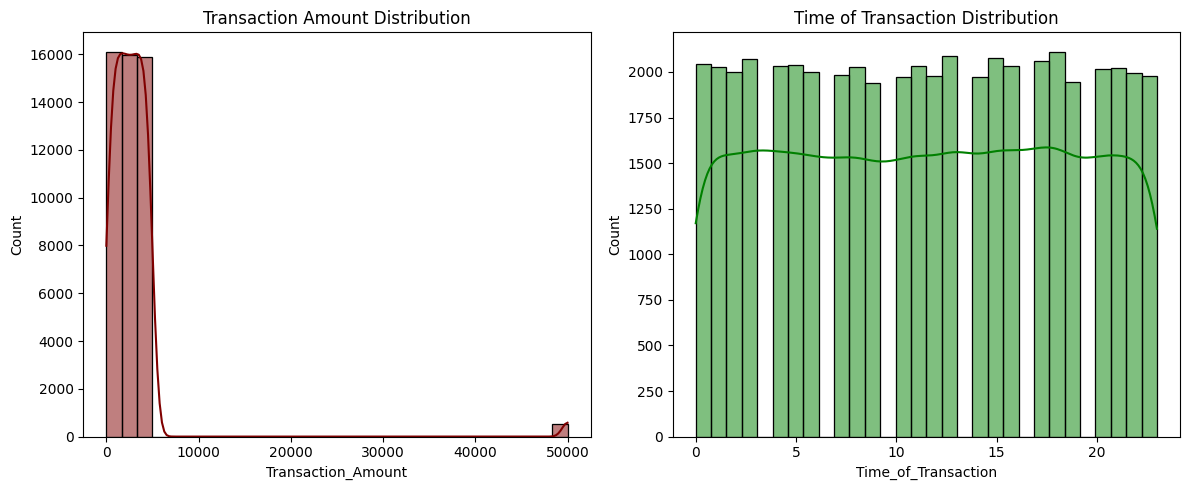

In [20]:
# Visual check of distributions for numerical columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(credit_fraud_detection_dataset["Transaction_Amount"].dropna(), bins=30, kde=True, color="maroon", ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')
axes[0].grid(False)
sns.histplot(credit_fraud_detection_dataset["Time_of_Transaction"].dropna(), bins=30, kde=True, color="green", ax=axes[1])
axes[1].set_title('Time of Transaction Distribution')
axes[1].grid(False)
plt.tight_layout()
plt.show()

In [21]:
# Impute based on skewness
numerical_columns = ["Transaction_Amount", "Time_of_Transaction"]
for col1 in numerical_columns:
    skewness = credit_fraud_detection_dataset[col1].skew()
    print(f"{col1} skewness: {skewness:.2f}")
    if abs(skewness) > 0.5:
        impute_value = credit_fraud_detection_dataset[col1].median()
        method = 'median'
    else:
        impute_value = credit_fraud_detection_dataset[col1].mean()
        method = 'mean'
    missing_count = credit_fraud_detection_dataset[col1].isnull().sum()
    credit_fraud_detection_dataset[col1] = credit_fraud_detection_dataset[col1].fillna(impute_value)
    print(f"{col1}: Filled {missing_count} missing values with {method} ({impute_value:.2f})")

Transaction_Amount skewness: 8.45
Transaction_Amount: Filled 2520 missing values with median (2524.10)
Time_of_Transaction skewness: -0.00
Time_of_Transaction: Filled 2552 missing values with mean (11.49)


In [24]:
round(credit_fraud_detection_dataset["Device_Used"].value_counts(normalize=True),4)*100

,proportion
Device_Used,
Desktop,30.97
Mobile,30.62
Tablet,30.56
Unknown,4.85
Unknown Device,3.00


In [23]:
round(credit_fraud_detection_dataset["Payment_Method"].value_counts(normalize=True),4)*100

,proportion
Payment_Method,
UPI,23.31
Debit Card,23.14
Net Banking,22.87
Credit Card,22.84
Unknown,4.84
Invalid Method,3.00


In [25]:
round(credit_fraud_detection_dataset.isnull().sum()/len(credit_fraud_detection_dataset.index),2)*100

,0
Transaction_ID,0.0
User_ID,0.0
Transaction_Amount,0.0
Transaction_Type,0.0
Time_of_Transaction,0.0
Device_Used,0.0
Location,0.0
Previous_Fraudulent_Transactions,0.0
Account_Age,0.0
Number_of_Transactions_Last_24H,0.0


In [22]:
# Handle categorical missing values
categorical_columns = ["Device_Used", "Payment_Method" ]
for col in categorical_columns:
    missing_count = credit_fraud_detection_dataset[col].isnull().sum()
    credit_fraud_detection_dataset[col] = credit_fraud_detection_dataset[col].fillna('Unknown')
    print(f"{col}: Filled {missing_count} missing values with 'Unknown'")

Device_Used: Filled 2473 missing values with 'Unknown'
Payment_Method: Filled 2469 missing values with 'Unknown'


In [27]:
# Dropping the rows with null values
credit_fraud_detection_dataset.dropna(inplace = True)

In [28]:
#checking for Duplicates
credit_fraud_detection_dataset[credit_fraud_detection_dataset.duplicated()]

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50000,T33554,2669,2425.71,Bank Transfer,14.0,Tablet,Seattle,2,40,7,UPI,0
50001,T9428,1001,2448.53,Bank Transfer,19.0,Mobile,San Francisco,4,7,3,Unknown,0
50002,T200,3790,4429.89,ATM Withdrawal,17.0,Unknown,Miami,1,39,6,UPI,1
50003,T12448,1743,108.00,ATM Withdrawal,15.0,Tablet,Los Angeles,3,67,9,Credit Card,0
50004,T39490,4329,2320.30,ATM Withdrawal,4.0,Desktop,Los Angeles,3,12,10,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50993,T5873,4911,3613.59,Online Purchase,11.0,Tablet,New York,3,58,7,Net Banking,0
50994,T48244,4842,1587.84,POS Payment,10.0,Tablet,New York,1,94,6,UPI,0
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1


In [29]:
credit_fraud_detection_dataset_clean = credit_fraud_detection_dataset.drop_duplicates()

In [30]:
credit_fraud_detection_dataset_clean.shape

(50119, 12)

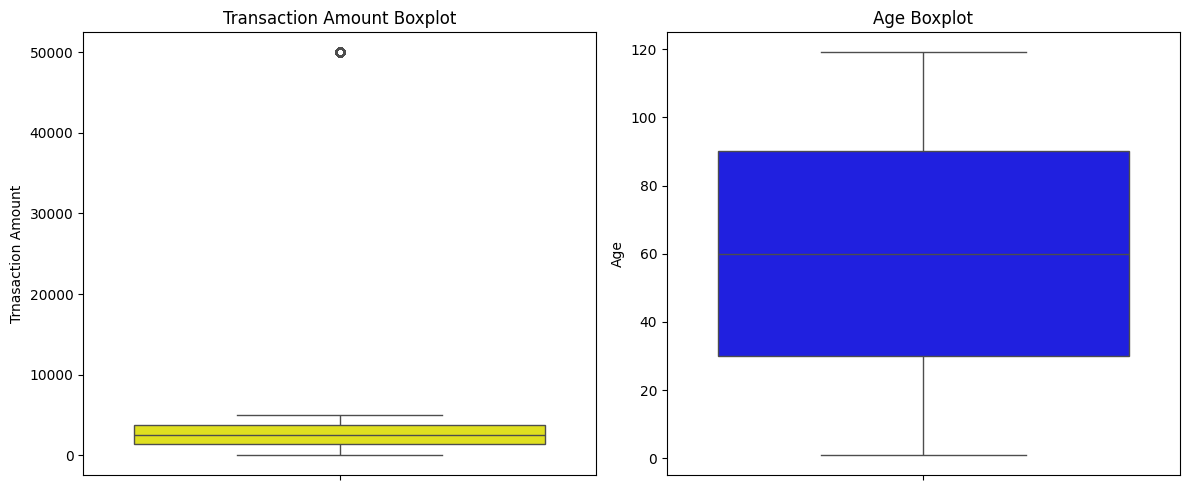

In [31]:
# Combined boxplots for key numerical columns (in subplots) and outlier reporting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=credit_fraud_detection_dataset_clean["Transaction_Amount"], ax=axes[0], color="yellow")
axes[0].set_title('Transaction Amount Boxplot')
axes[0].set_ylabel("Trnasaction Amount")
axes[0].grid(False)
sns.boxplot(y=credit_fraud_detection_dataset_clean["Account_Age"], ax=axes[1], color="blue")
axes[1].set_title('Age Boxplot')
axes[1].set_ylabel('Age')
axes[1].grid(False)
plt.tight_layout()
plt.show()

In [1]:
credit_fraud_detection_dataset_clean.head()

NameError: name 'credit_fraud_detection_dataset_clean' is not defined

In [ ]:
#Developing synthetic dataset
#Finding fraudscore
#Normalizing dataset
#Normalizing the columns by creating a normalize function
def normalize(columns):
  return (columns - columns.min()) / (columns.max() - columns.min())

credit_fraud_detection_dataset["Normalized_Amt"] = normalize(credit_fraud_detection_dataset["Transaction_Amount"])

credit_fraud_detection_dataset["Normalized_History"] = normalize(credit_fraud_detection_dataset["Previous_Fraudulent_Transactions"])

credit_fraud_detection_dataset["Normalized_Frequency"] = normalize(credit_fraud_detection_dataset["Number_of_Transactions_Last_24H"])

credit_fraud_detection_dataset["Nomalized_Age"] = 1 - normalize(credit_fraud_detection_dataset["Account_Age"])

#Assign risk weights to transaction time
def time_risk(hour):
  if hour <= 0 and hour <= 5: #Night Time transactions are considered suspicious
    return 1
  elif hour <= 6 and hour <= 8: #Morning transactions are considered normal
    return 0.6
  elif hour <= 9 and hour <= 20: #Midday transactions are considered normal
    return 0.4
  else:
    return 0.5
credit_fraud_detection_dataset["Time_Risk"] = credit_fraud_detection_dataset["Time_of_Transaction"].apply(time_risk)
#credit_fraud_detection_dataset.head()
Transaction_Type_Risk = {
    "Bill Payment":0.2,
    "ATM Withdrawal":0.4,
    "POS Payment":0.6,
    "Bank Transfer":0.7,
    "Online Purchase":0.8
}
credit_fraud_detection_dataset["Normalized_Transaction_Type"] = credit_fraud_detection_dataset["Transaction_Type"].map(Transaction_Type_Risk)
device_risk = {
    "Mobile":0.4,
    "Desktop":0.3,
    "Tablet":0.5,
    "Unknown Device":1.0
}
credit_fraud_detection_dataset["Normalized_Device"]= credit_fraud_detection_dataset["Device_Type"].map(device_risk)
Location_risk = {
    "Boston":0.4,
    "Chicago":0.3,
    "Houston":0.5,
    "New York":0.6,
    "Los Angeles":0.7
    "Miami":,
    "San Francisco":0.8
}
    "Unknown Device":1.0
}
credit_fraud_detection_dataset["Normalized_Device"]= credit_fraud_detection_dataset["Device_Type"].map(device_risk)

credit_fraud_detection_dataset.head()
